In [1]:
from pyscripts.plotting_utils import *

In [7]:
base_models, model_prefixes = ['X013-2'], ['CR_small_']#[f'X013-{i}' for i in [1, 2, 3, 4]], ['OX_', 'DA_', 'DA_stretch_', 'CR_', 'BR_', 'HIV1p_']

In [6]:
show = True

for base_model in base_models:
    f = open(f"best_model_list_{base_model}.txt", 'w')
    for model_pre in model_prefixes:
        model_name2load = model_pre + base_model
        print(model_name2load)
        fns = glob.glob(f'numpy_backups/{model_name2load}/*/*/*.npy')
        print(fns)
        chart_data = load_files(fns, verbose=False)
        means, best_rpts_rmsd, best_rpts_loss = lowest_rpts(chart_data)
        for i, rpt in enumerate(best_rpts_rmsd.values()):
            if i == len(best_rpts_rmsd) - 1:
                lat = pref2heavycount[model_pre]
            else:
                lat = print_lat(i)
            json_fn = f"json_inputs/{base_model}/{model_name2load}/{model_name2load}_{lat:04d}_{int(rpt[-1]):02d}.json\n"
            f.write(json_fn)
    f.close()
    print(base_model)
        #print(best_rpts_loss)

HEWL_X013-2
[]


IndexError: list index out of range

CR_small_X013-2
['CR_small_X013-2', '0001_latents', 'rpt_1', 'PCA_LOSS_RMSD.npy']
['CR_small_X013-2', '0001_latents', 'rpt_1', 'PCA_RMSD.npy']
['CR_small_X013-2', '0001_latents', 'rpt_1', 'VAE_LOSS_RMSD.npy']
['CR_small_X013-2', '0001_latents', 'rpt_1', 'VAE_RMSD.npy']
['CR_small_X013-2', '0001_latents', 'rpt_2', 'PCA_LOSS_RMSD.npy']
['CR_small_X013-2', '0001_latents', 'rpt_2', 'PCA_RMSD.npy']
['CR_small_X013-2', '0001_latents', 'rpt_2', 'VAE_LOSS_RMSD.npy']
['CR_small_X013-2', '0001_latents', 'rpt_2', 'VAE_RMSD.npy']
['CR_small_X013-2', '0001_latents', 'rpt_3', 'PCA_LOSS_RMSD.npy']
['CR_small_X013-2', '0001_latents', 'rpt_3', 'PCA_RMSD.npy']
['CR_small_X013-2', '0001_latents', 'rpt_3', 'VAE_LOSS_RMSD.npy']
['CR_small_X013-2', '0001_latents', 'rpt_3', 'VAE_RMSD.npy']
['CR_small_X013-2', '0001_latents', 'rpt_4', 'PCA_LOSS_RMSD.npy']
['CR_small_X013-2', '0001_latents', 'rpt_4', 'PCA_RMSD.npy']
['CR_small_X013-2', '0001_latents', 'rpt_4', 'VAE_LOSS_RMSD.npy']
['CR_small_X013-2', '0001_lat

<Figure size 640x480 with 0 Axes>

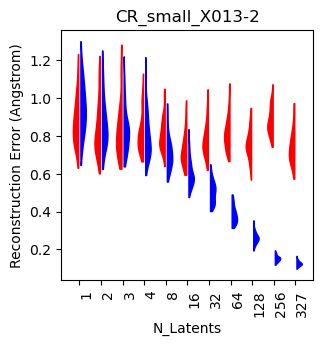

Done!


In [8]:
show = True

for base_model in base_models:
    for model_pre in model_prefixes:
        model_name2load = model_pre + base_model
        print(model_name2load)
        chart_data = load_files(glob.glob(f'numpy_backups/{model_name2load}/*/*/*.npy'), verbose=False)
        means, best_rpts_rmsd, best_rpts_loss = lowest_rpts(chart_data)
        
        vae_rmsds =      {key: val[best_rpts_rmsd[key]]['VAE_RMSD']      for key, val in chart_data.items()}
        vae_loss_rmsds = {key: val[best_rpts_loss[key]]['VAE_LOSS_RMSD'] for key, val in chart_data.items()}
        pca_rmsds =      {key: val[best_rpts_rmsd[key]]['PCA_RMSD']      for key, val in chart_data.items()}
        pca_loss_rmsds = {key: val[best_rpts_loss[key]]['PCA_LOSS_RMSD'] for key, val in chart_data.items()}
        
        latents = [int(key) for key in vae_rmsds]
    
        figure_dir = os.path.join(os.getcwd(), f'figures/{model_name2load}/')
        if not os.path.isdir(figure_dir):
            os.makedirs(figure_dir, exist_ok=True)
        try:
            _ = violin_plots(vae_rmsds, pca_rmsds, latents, model_name2load, model_pre,
                         ceil=10.0, num_stds=3, show=show, figure_dir=figure_dir)
        except:
            print(base_model, model_pre, 'had a failure while plotting...')
print("Done!")

In [5]:
figure_generation_logs = sorted(glob.glob('./figures/*/figure_generation_log.txt'))

In [6]:
csv_direc = './tables/csvs_violin/'

for log_fn in figure_generation_logs:
    csv_name = os.path.join(csv_direc, log_fn.split('/')[-2] + '_violin_health_report.csv')
    csv_contents = figure_log_to_csv(log_fn)
    with open(csv_name, 'w') as f:
        f.write(csv_contents)

In [7]:
reorganize_figures_and_logs('./figures/')